<a href="https://colab.research.google.com/github/w3aarush/DR_Classification_NIT_MCA_Project/blob/main/simple_vanilla_cnn_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# libraries

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import numpy as np
from tensorflow.keras.callbacks import ModelCheckpoint
# import Earlystopping
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
import cv2

In [3]:
NUM_CLASS = 5

# dataset loading

In [4]:
# from drive
base_dir = '/content/drive/MyDrive/aptos2019/'
train_img = '/content/drive/MyDrive/aptos2019/train_images/train_images/'
validation_img = '/content/drive/MyDrive/aptos2019/val_images/val_images/'
test_img = '/content/drive/MyDrive/aptos2019/test_images/test_images/'

train_csv = '/content/drive/MyDrive/aptos2019/train_1.csv'
test_csv = '/content/drive/MyDrive/aptos2019/test.csv'
valid_csv = '/content/drive/MyDrive/aptos2019/valid.csv'

In [5]:
def load_data():
    # train = pd.read_csv('/content/aptos2019/train_1.csv', encoding='utf-8')
    # test = pd.read_csv('/content/aptos2019/test.csv', encoding='utf-8')
    # valid = pd.read_csv('/content/aptos2019/valid.csv')

    train = pd.read_csv(train_csv, encoding='utf-8') # from drive
    test = pd.read_csv(test_csv, encoding='utf-8') # from drive
    valid = pd.read_csv(valid_csv) # from drive

    # train_dir = '/content/aptos2019/train_images/train_images/'
    # test_dir = '/content/aptos2019/test_images/test_images/'
    # valid_dir = '/content/aptos2019/val_images/val_images/'

    train_dir = train_img # from drive
    test_dir = test_img # from drive
    valid_dir = validation_img # from drive

    # construct file paths directly within function:
    train['image_path'] = train_dir + train['id_code'] + '.png'
    test['image_path'] = test_dir + test['id_code'] + '.png'
    valid['image_path'] = valid_dir + valid['id_code'] + '.png'

    train['train_images'] = train['id_code'] + '.png'
    test['test_images'] = test['id_code'] + '.png'
    valid['valid_images'] = valid['id_code'] + '.png'

    train['diagnosis'] = train['diagnosis'].astype(str)
    # train['target'] = [1 if x >= 1 else 0 for x in train['diagnosis']]
    # train['target'] = train['target'].astype(str)
    test['diagnosis'] = test['diagnosis'].astype(str)
    # test['target'] = [1 if x >= 1 else 0 for x in test['diagnosis']]
    # test['target'] = test['target'].astype(str)
    valid['diagnosis'] = valid['diagnosis'].astype(str)
    # valid['target'] = [1 if x >= 1 else 0 for x in valid['diagnosis']]
    # valid['target'] = valid['target'].astype(str)

    return train, test, valid

In [6]:
train_df, test_df, valid_df = load_data()

## preprocessing

In [7]:
def auto_crop_retina(img, tol=7):
    """
    Finds the circular retinal mask and crops out the black borders.
    """
    # Convert to grayscale to find the mask
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray_img > tol

    # If the image is completely dark, return the original to avoid errors
    if img[:,:,0][np.ix_(mask.any(1),mask.any(0))].shape[0] == 0:
        return img

    # Crop all three channels based on the mask
    img1 = img[:,:,0][np.ix_(mask.any(1),mask.any(0))]
    img2 = img[:,:,1][np.ix_(mask.any(1),mask.any(0))]
    img3 = img[:,:,2][np.ix_(mask.any(1),mask.any(0))]

    return np.stack([img1, img2, img3], axis=-1)

def enhance_retinal_image(image_array):
    """
    The main function to pass to Keras ImageDataGenerator.
    """
    # Keras passes a float array; OpenCV needs uint8
    img = image_array.astype(np.uint8)

    # Step 1: Crop the black borders
    img = auto_crop_retina(img)

    # Step 2: Resize early to ensure consistent grid sizing for CLAHE
    img = cv2.resize(img, (224, 224))

    # Step 3: Apply CLAHE
    # We convert to LAB color space and apply CLAHE *only* to the L (Lightness)
    # channel. This enhances contrast without distorting the actual colors.
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)

    # Merge channels back and convert to RGB
    enhanced_lab = cv2.merge((cl, a, b))
    final_img = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)

    # Return as float32 for Keras
    return final_img.astype(np.float32)

## visualising preprocessed images

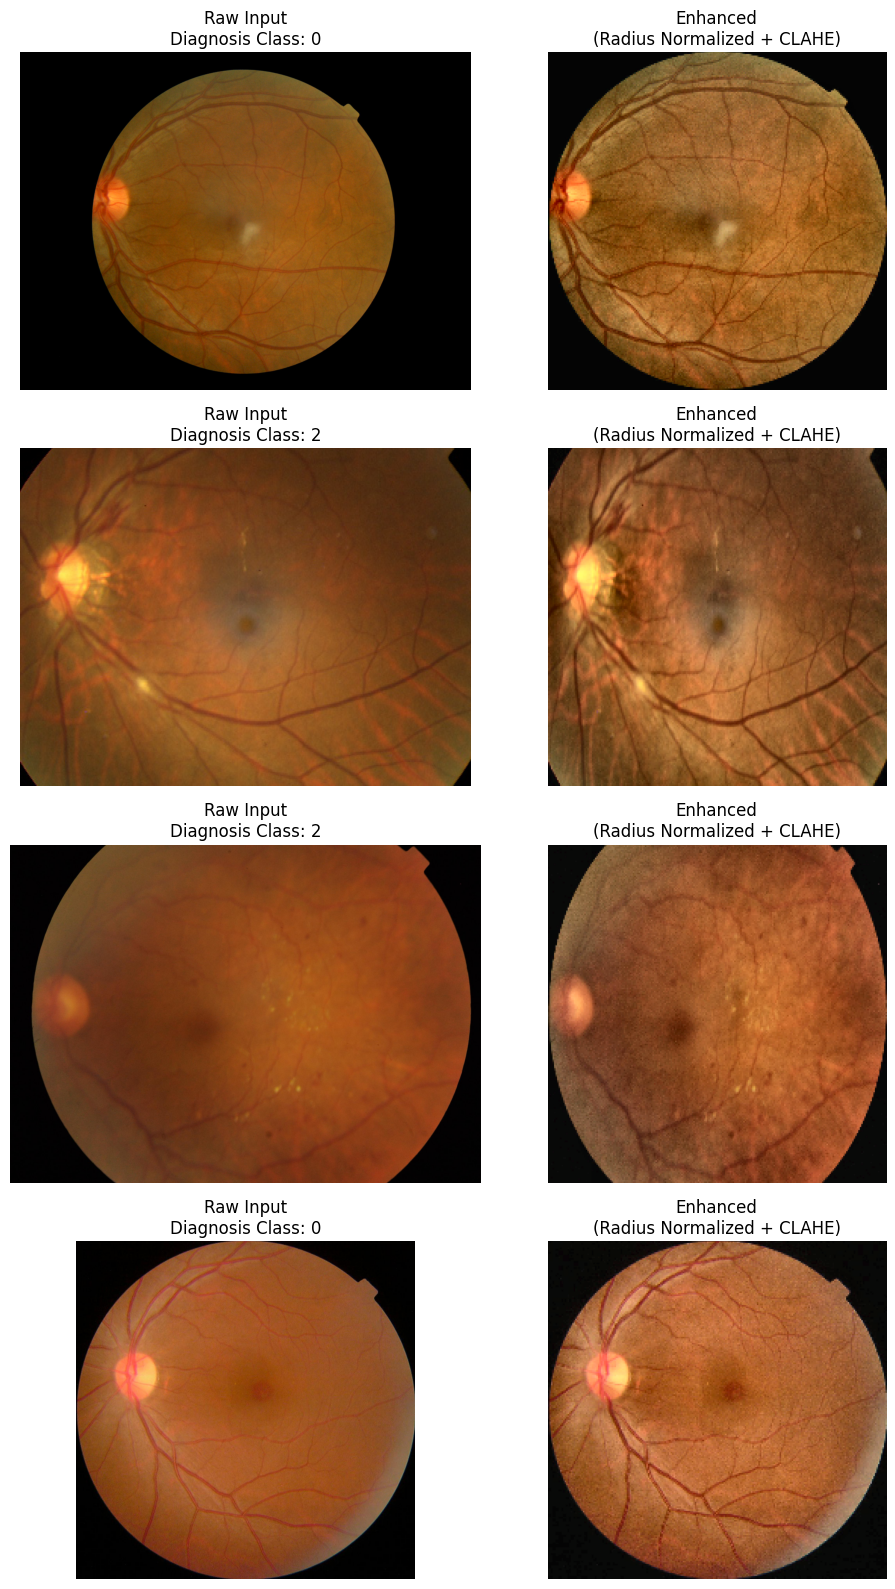

In [8]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def visualize_preprocessing_impact(df, num_samples=3):
    """
    Randomly selects images from the dataframe and plots the
    Vanilla (Raw) vs. Enhanced (Radius Normalization + CLAHE) versions.
    """
    # Randomly sample images to get a varied look
    sample_df = df.sample(n=num_samples)

    # Set up the plotting grid
    plt.figure(figsize=(10, 4 * num_samples))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        # 1. Load the raw image
        img_path = row['image_path']
        raw_img = cv2.imread(img_path)

        # OpenCV loads as BGR, convert to RGB for accurate display
        raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

        # 2. Apply your custom enhancement pipeline
        enhanced_img = enhance_retinal_image(raw_img)

        # Matplotlib expects float arrays to be scaled between 0 and 1
        if enhanced_img.dtype == np.float32:
            display_enhanced = np.clip(enhanced_img / 255.0, 0, 1)
        else:
            display_enhanced = enhanced_img

        # Plot Raw (Left Side)
        plt.subplot(num_samples, 2, 2*i + 1)
        plt.imshow(raw_img)
        plt.title(f"Raw Input\nDiagnosis Class: {row['diagnosis']}")
        plt.axis('off')

        # Plot Enhanced (Right Side)
        plt.subplot(num_samples, 2, 2*i + 2)
        plt.imshow(display_enhanced)
        plt.title(f"Enhanced\n(Radius Normalized + CLAHE)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Execute the function using your existing dataframe
visualize_preprocessing_impact(train_df, num_samples=4)

# Dataset batch generation

In [9]:
# datagen = ImageDataGenerator(rescale=1./255)
datagen = ImageDataGenerator(
    preprocessing_function=enhance_retinal_image,
    rescale=1./255
)

In [10]:
train_batches = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='diagnosis',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
val_batches = datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col='image_path',
    y_col='diagnosis',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
test_batches = datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='diagnosis',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2930 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.


### Verify Preprocessing on a Sample Batch

Shape of images in a batch: (32, 224, 224, 3)
Shape of labels in a batch: (32, 5)


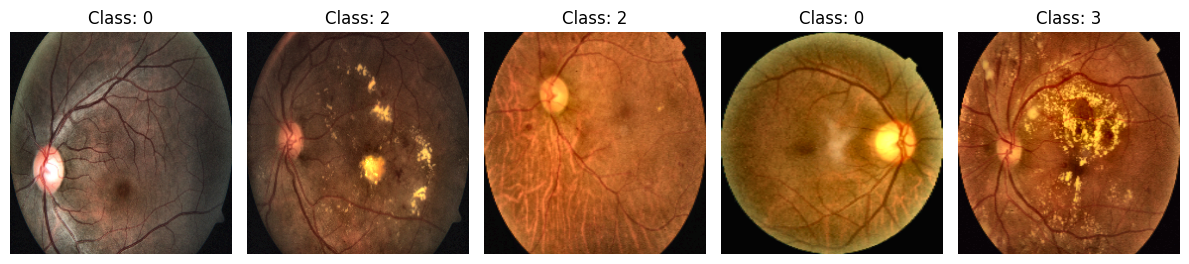

If the images above appear cropped and enhanced, your `enhance_retinal_image` function is working correctly with the `ImageDataGenerator`.


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of images and labels from the training generator
sample_images, sample_labels = next(train_batches)

print(f"Shape of images in a batch: {sample_images.shape}")
print(f"Shape of labels in a batch: {sample_labels.shape}")

# Display a few images from the batch
plt.figure(figsize=(12, 8))
for i in range(min(5, sample_images.shape[0])):
    plt.subplot(1, 5, i + 1)
    # ImageDataGenerator rescales to [0,1], so no need to divide by 255
    plt.imshow(sample_images[i])
    # Convert one-hot encoded label back to class index for display
    diagnosis_class = np.argmax(sample_labels[i])
    plt.title(f"Class: {diagnosis_class}")
    plt.axis('off')
plt.tight_layout()
plt.show()

print("If the images above appear cropped and enhanced, your `enhance_retinal_image` function is working correctly with the `ImageDataGenerator`.")

# Dataset Distribution

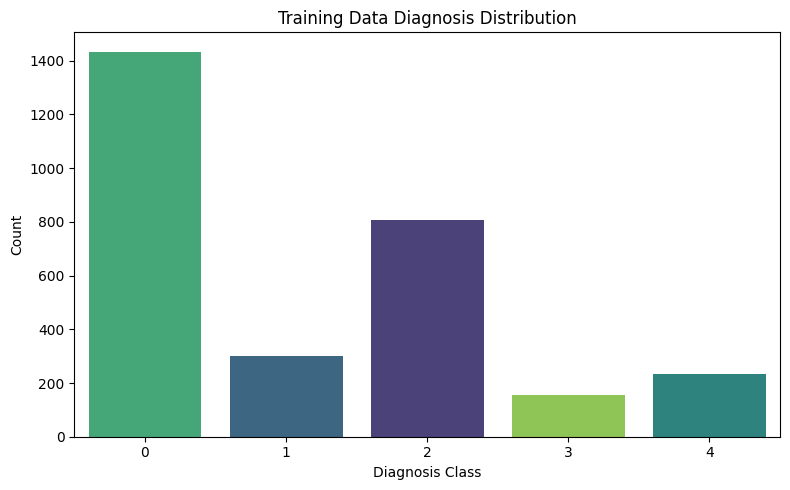

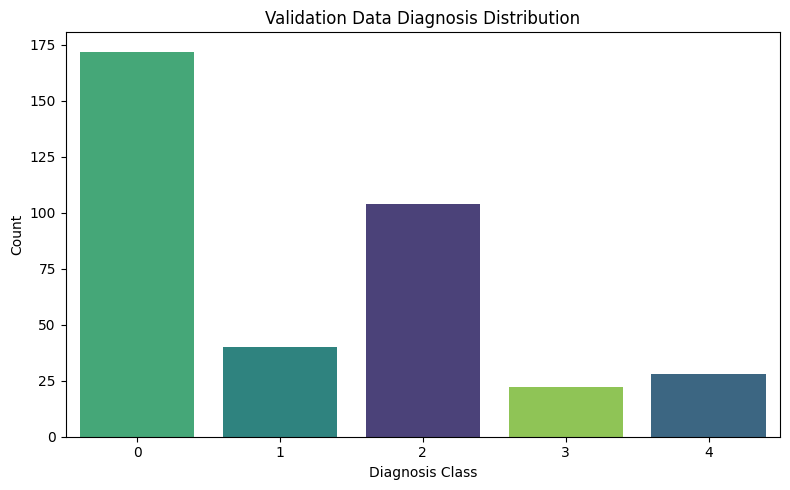

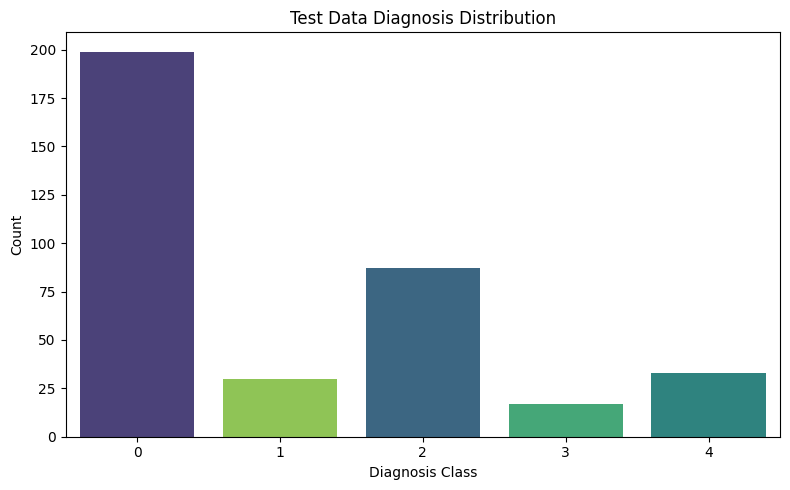

Diagnosis distribution in training data:
 diagnosis
0    1434
2     808
1     300
4     234
3     154
Name: count, dtype: int64

Diagnosis distribution in validation data:
 diagnosis
0    172
2    104
1     40
4     28
3     22
Name: count, dtype: int64

Diagnosis distribution in test data:
 diagnosis
0    199
2     87
4     33
1     30
3     17
Name: count, dtype: int64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the order for the diagnosis classes
class_order = ['0', '1', '2', '3', '4']

# Create a list of dataframes, titles, and filenames
datasets = [
    (train_df, 'Training Data Diagnosis Distribution', '/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/train_diagnosis_distribution.png'),
    (valid_df, 'Validation Data Diagnosis Distribution', '/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/validation_diagnosis_distribution.png'),
    (test_df, 'Test Data Diagnosis Distribution', '/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/test_diagnosis_distribution.png')
]

for df, title, filename in datasets:
    plt.figure(figsize=(8, 5))
    sns.countplot(x='diagnosis', data=df, palette='viridis', hue='diagnosis', legend=False, order=class_order)
    plt.title(title)
    plt.xlabel('Diagnosis Class')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

print("Diagnosis distribution in training data:\n", train_df['diagnosis'].value_counts())
print("\nDiagnosis distribution in validation data:\n", valid_df['diagnosis'].value_counts())
print("\nDiagnosis distribution in test data:\n", test_df['diagnosis'].value_counts())

# Model Definition

In [15]:
def get_vanilla_cnn(input_shape=(224, 224, 3), num_classes=NUM_CLASS):
    model = models.Sequential([
        # block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        # flatten
        layers.Flatten(),


        # dense layers
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),

        # layers.Dense(128, activation='relu'),
        # layers.Dropout(0.5),

        # layers.Dense(64, activation='relu'),
        # layers.Dropout(0.5),

        # layers.Dense(32, activation='relu'),
        # layers.Dropout(0.5),

        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Initialize and compile
model = get_vanilla_cnn()
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,395,909 (73.99 MB)

 Trainable params: 19,395,909 (73.99 MB)

 Non-trainable params: 0 (0.00 B)

# Model training

In [16]:
CHECKPOINT_SAVE_PATH = '/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/checkpoint/checkpoint_simple_vanilla_cnn.keras'

In [17]:
callbacks = [
    ModelCheckpoint(filepath= CHECKPOINT_SAVE_PATH, save_best_only=True, monitor='val_accuracy', mode='max', verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-4, verbose=1)
]

In [18]:
# training the model
history = model.fit(
    train_batches,
    validation_data = val_batches,
    epochs = 20,
    verbose = 1,
    callbacks = callbacks
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.5665 - loss: 1.1600 
Epoch 1: val_accuracy improved from None to 0.68579, saving model to /content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/checkpoint/checkpoint_simple_vanilla_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/checkpoint/checkpoint_simple_vanilla_cnn.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 1666s 18s/step - accuracy: 0.6437 - loss: 1.0149 - val_accuracy: 0.6858 - val_loss: 0.8155 - learning_rate: 0.0010
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7036 - loss: 0.8633
Epoch 2: val_accuracy did not improve from 0.68579
92/92 ━━━━━━━━━━━━━━━━━━━━ 545s 6s/step - accuracy: 0.7055 - loss: 0.8598 - val_accuracy: 0.6749 - val_loss: 0.8131 - learning_rate: 0.0010
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7050 - loss: 0.8460
Epoch 3: val_accuracy did not improve from 0.68579
92/92 ━━━━━

In [19]:
model.save("/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/dr_simple_vanilla_cnn_preprocessing_phase2.keras")

In [20]:
history_df = pd.DataFrame(history.history)
history_df.to_csv("/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/dr_simple_vanilla_cnn_phase2_history.csv")

# Epoch training result

In [21]:
history_df = pd.read_csv("/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/dr_simple_vanilla_cnn_phase2_history.csv")
history_df

,Unnamed: 0,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0,0.643686,1.014886,0.685792,0.815469,0.0010
1,1,0.705461,0.859788,0.674863,0.813053,0.0010
2,2,0.706826,0.844317,0.650273,0.897414,0.0010
3,3,0.706143,0.827503,0.672131,0.814571,0.0010
4,4,0.711604,0.818415,0.715847,0.743554,0.0010
5,5,0.718430,0.790098,0.715847,0.746317,0.0010
6,6,0.712628,0.794598,0.702186,0.759860,0.0010
7,7,0.726621,0.764392,0.721311,0.755083,0.0010
8,8,0.724915,0.756588,0.715847,0.789255,0.0010
9,9,0.735154,0.737030,0.724044,0.734035,0.0010


# Val_accuacy & train_accuracy line chart

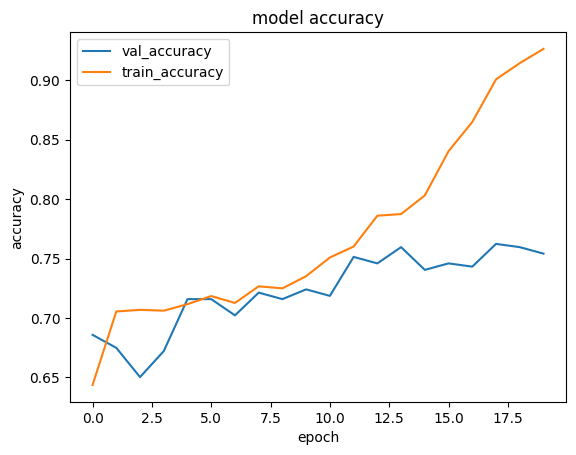

In [22]:
# plot val_accuracy and train_accuracy
import matplotlib.pyplot as plt
plt.plot(history_df['val_accuracy'])
plt.plot(history_df['accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['val_accuracy', 'train_accuracy'], loc='upper left')
plt.savefig('/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/simple_vanilla_phase2_accuracy.png')
plt.show()

# train_loss and val_loss chart

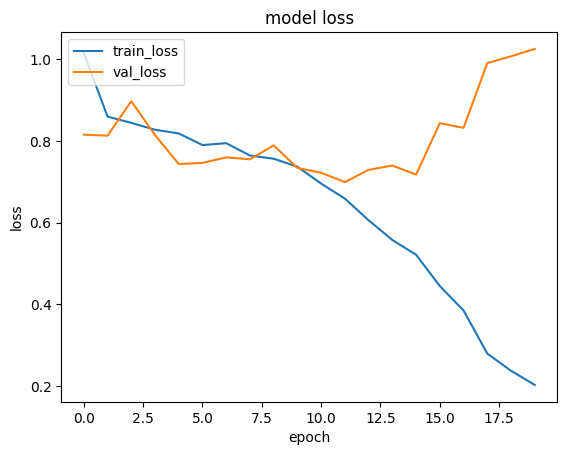

In [23]:
# plot val_loss and train_loss
plt.plot(history_df['loss'])
plt.plot(history_df['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'], loc='upper left')
plt.savefig('/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/simple_vanilla_phase2_loss.png')
plt.show()

# loading model

In [ ]:
# load model
from keras.models import load_model
model = load_model("/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/dr_simple_vanilla_cnn_phase2.keras")

# Evalting Model

In [24]:
loss, accuracy = model.evaluate(test_batches)

12/12 ━━━━━━━━━━━━━━━━━━━━ 152s 13s/step - accuracy: 0.7705 - loss: 0.8908


In [25]:
loss

0.8907959461212158

In [26]:
accuracy

0.7704917788505554

# <font color="yellow">classification report</font>

In [27]:
# classification report
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
import numpy as np

In [28]:
Y_pred = model.predict(test_batches)
y_pred = np.argmax(Y_pred, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step


In [29]:
# classification report
print('Classification Report')
# target_names = ['class 0(0)', 'class 1(1)', 'class 2(2)', 'class 3(3)', 'class 4(4)']
print(classification_report(test_batches.classes, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       199
           1       0.38      0.40      0.39        30
           2       0.62      0.74      0.67        87
           3       0.25      0.24      0.24        17
           4       0.67      0.30      0.42        33

    accuracy                           0.77       366
   macro avg       0.57      0.53      0.54       366
weighted avg       0.77      0.77      0.76       366



# <font color="yellow">tabulated classification report</font>


In [30]:
import pandas as pd
from sklearn.metrics import classification_report

# Generate the classification report as a dictionary
report = classification_report(test_batches.classes, y_pred, output_dict=True)

# Convert the report dictionary to a pandas DataFrame
df_report = pd.DataFrame(report).transpose()

# Save the DataFrame to a CSV file
report_filepath = '/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/classification_report.csv'
df_report.to_csv(report_filepath)

print(f"Classification report saved to: {report_filepath}")
display(df_report)

Classification report saved to: /content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/classification_report.csv


,precision,recall,f1-score,support
0,0.960000,0.964824,0.962406,199.000000
1,0.375000,0.400000,0.387097,30.000000
2,0.621359,0.735632,0.673684,87.000000
3,0.250000,0.235294,0.242424,17.000000
4,0.666667,0.303030,0.416667,33.000000
accuracy,0.770492,0.770492,0.770492,0.770492
macro avg,0.574605,0.527756,0.536456,366.000000
weighted avg,0.772126,0.770492,0.763971,366.000000


In [31]:
df_report_styled = df_report.style.background_gradient(cmap='viridis')
display(df_report_styled)

,precision,recall,f1-score,support
0,0.960000,0.964824,0.962406,199.000000
1,0.375000,0.400000,0.387097,30.000000
2,0.621359,0.735632,0.673684,87.000000
3,0.250000,0.235294,0.242424,17.000000
4,0.666667,0.303030,0.416667,33.000000
accuracy,0.770492,0.770492,0.770492,0.770492
macro avg,0.574605,0.527756,0.536456,366.000000
weighted avg,0.772126,0.770492,0.763971,366.000000


## <font color = 'yellow'>Confusion Matrix</font>

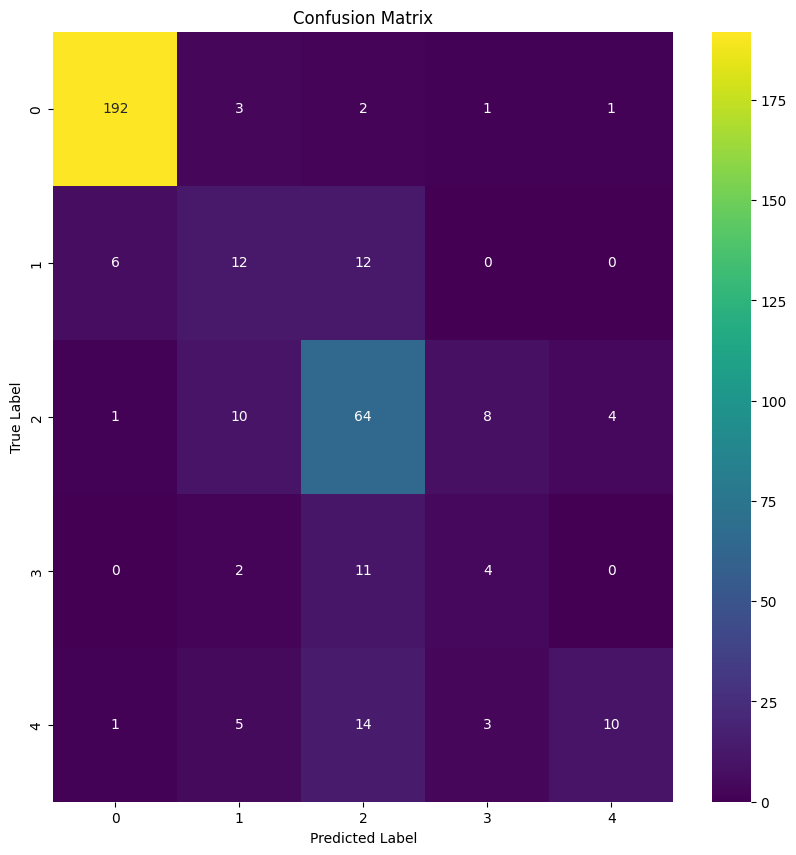

In [32]:
# confusion matrix
cm = confusion_matrix(test_batches.classes, y_pred)
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, cmap = 'viridis', fmt='d', xticklabels=[0, 1, 2, 3, 4], yticklabels=[0, 1, 2, 3, 4])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/simple_vanilla_phase2_confusion_matrix.png')
plt.show()

## <font color = 'yellow'>Normalised Confusion Matrix</font>

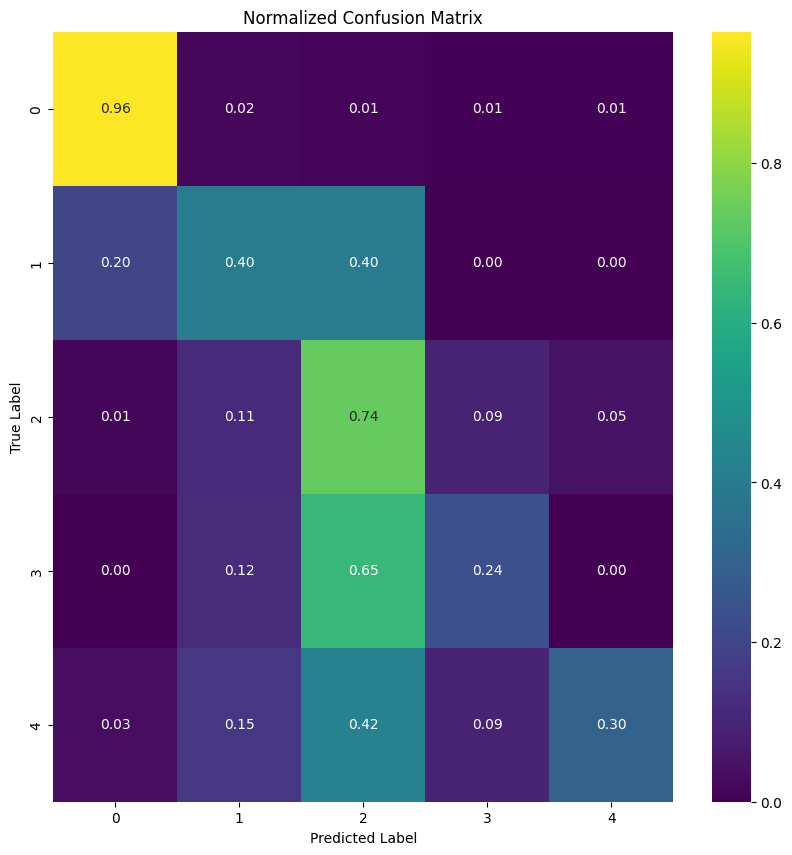

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Normalize the confusion matrix
# Divide each row by the sum of the row to get percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 10))
sns.heatmap(cm_normalized, annot=True, cmap='viridis', fmt='.2f', xticklabels=np.arange(NUM_CLASS), yticklabels=np.arange(NUM_CLASS))
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/simple_vanilla_normalized_confusion_matrix.png')
plt.show()

# <font color='yellow'>Model Architrecture</font>

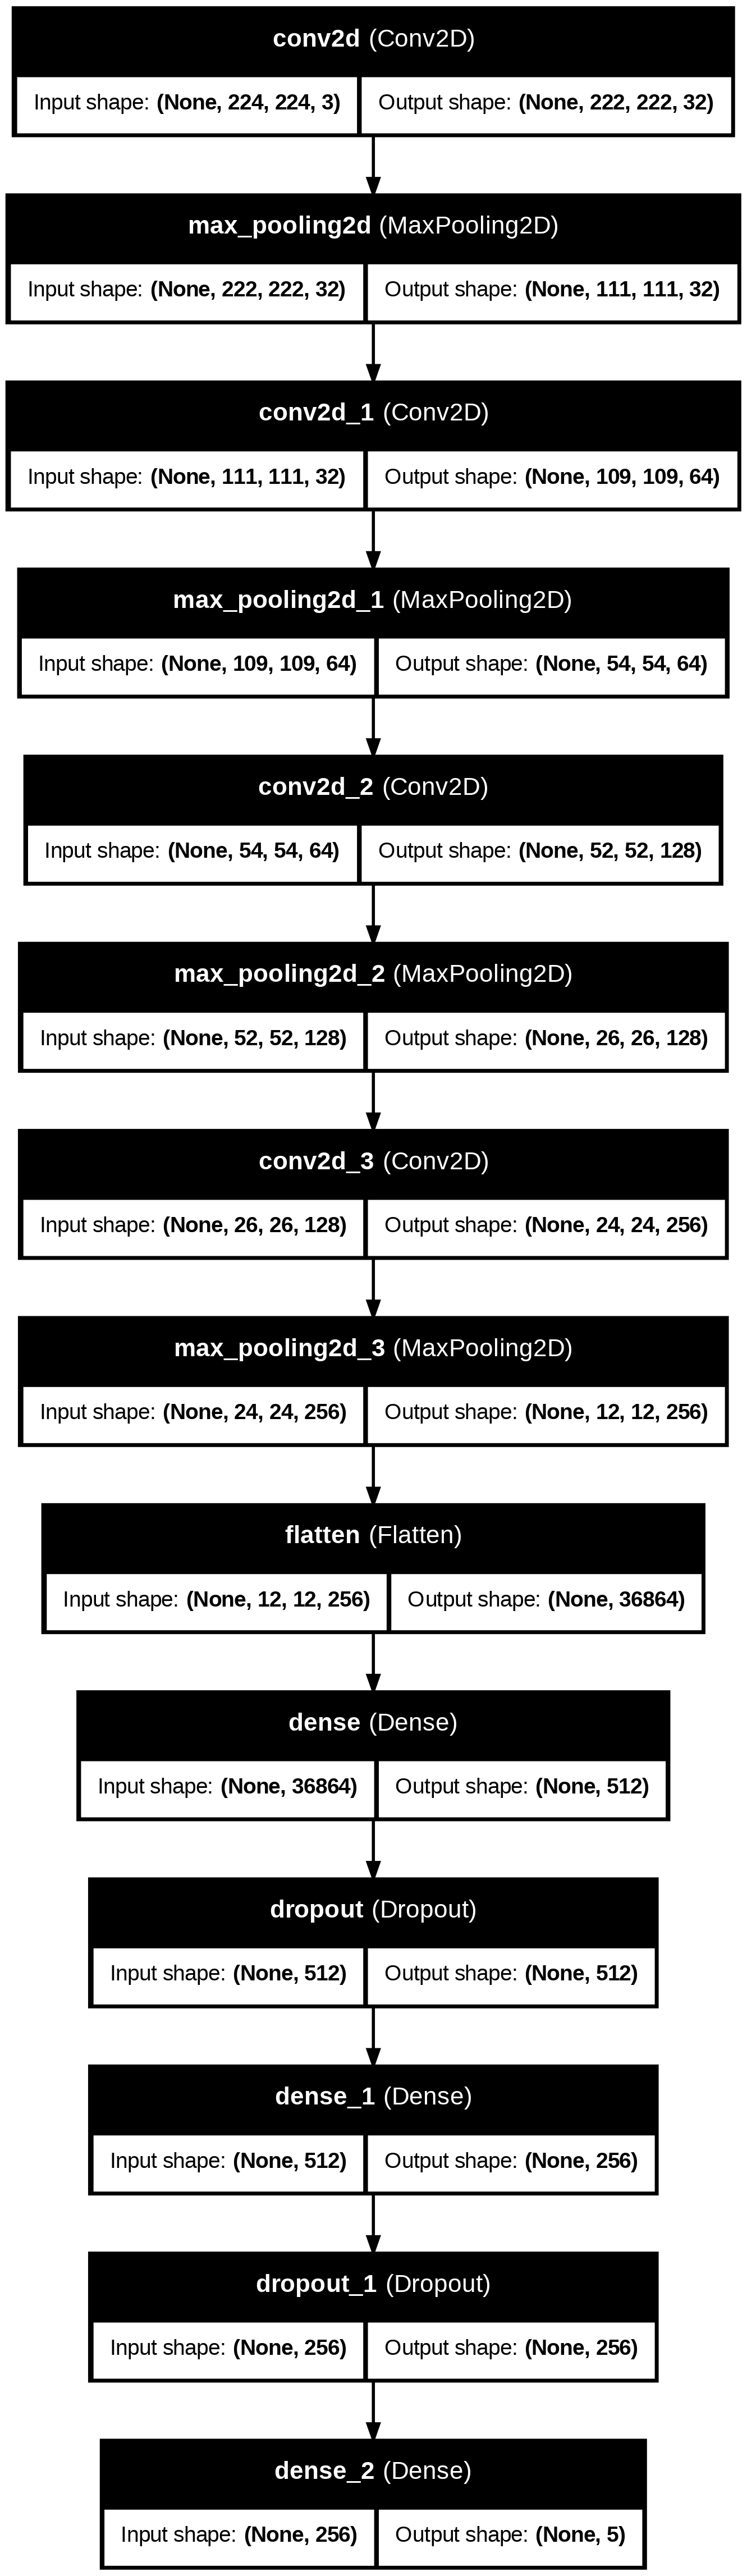

In [34]:
from tensorflow.keras.utils import plot_model

# 'model' is your compiled Keras model
plot_model(model, to_file='/content/drive/MyDrive/NIT_DR_Project/simple_vanilla_cnn_preprocessing_phase2/model_architecture.png', show_shapes=True, show_layer_names=True)

# next plan

Enhance Data Augmentation: You are currently using preprocessing_function and rescale. To make your model more robust and less prone to memorizing training data, you can introduce more transformations within the ImageDataGenerator. Consider:

rotation_range: Randomly rotate images.
width_shift_range and height_shift_range: Shift images horizontally or vertically.
shear_range: Apply shearing transformations.
zoom_range: Randomly zoom in on images.
horizontal_flip: Flip images horizontally.
fill_mode: How to fill in new pixels created by transformations (e.g., 'nearest', 'reflect').
Example: ImageDataGenerator(preprocessing_function=enhance_retinal_image, rescale=1./255, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')

Add Regularization (L2/L1): Regularization penalizes large weights in the network, encouraging the model to learn simpler patterns. L2 regularization is a common choice. You can add it to your Conv2D and Dense layers.

Example for a layer: layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=tf.keras.regularizers.l2(0.001))

Increase Dropout: You already have dropout layers. You could experiment with:

Higher Dropout Rates: Increase the dropout rate (e.g., from 0.5 to 0.6 or 0.7) in your dense layers.
More Dropout Layers: Add dropout layers after some of your convolutional blocks to regularize feature maps.
Introduce Batch Normalization: Batch Normalization helps stabilize and speed up training, and it acts as a form of regularization. It's typically added after convolutional layers and before activation functions, or between the activation and the next layer.

Example for a block: layers.Conv2D(32, (3, 3), use_bias=False), layers.BatchNormalization(), layers.ReLU()

Adjust Learning Rate Schedule: While ReduceLROnPlateau is good, sometimes a more aggressive or different schedule might be beneficial. You could also try different optimizers or fine-tune their parameters.

Simplify Model Architecture (if necessary): If the above methods don't fully resolve overfitting, your model might still be too complex for the amount of data you have. You could try reducing the number of filters in some convolutional layers or reducing the number of neurons in dense layers.